# Route Optimisation Analytics and Logistic Regression Model

This notebook analyses delivery zone distribution and builds a logistic regression model to predict whether an incoming order falls within a high-density delivery zone.

## Problem Statement
Astoria currently dispatches riders reactively, assigning them after orders arrive rather than pre-positioning them in areas of expected demand. With 20 delivery zones spread across Singapore, not all zones receive equal order volume. Certain zones consistently attract higher order concentration, yet riders are not proactively allocated there. This leads to delayed pickups, over-utilisation in busy zones and idle time in quieter ones. 

## Business Objective
- Identify which delivery zones consistently receive higher order volumes
- Understand the geographic and operational factors that characterise high-density zones
- Build a predictive model that classifies an incoming order as high-density or low-density at the point of booking
- Use these predictions to pre-assign riders before collection slots begin, improving route efficiency and reducing wait times


## Recommended Features

Used in the model:
- `latitude` — geographic north-south position of the customer address
- `longitude` — geographic east-west position; strongest single predictor of zone
- `region_enc` — encoded broad region (Central, East, West, North, North-East)
- `booking_hour` — hour of day the order was placed; peak hours may cluster in certain zones
- `dow_num` — numeric day of week (0 = Monday, 5 = Saturday)
- `month` — month of year to capture seasonal zone-level demand shifts
- `order_value_sgd` — higher-value orders may skew toward central or residential zones
- `effort_score` — service complexity (1–5); premium services may cluster geographically
- `quantity` — number of items in the order
- `is_express` — binary flag for express orders; time-sensitive orders may reflect zone behaviour
- `is_free_del` — binary flag for orders above the free delivery threshold ($40)
- `del_slot_enc` — encoded delivery slot preference (0 = 9am–1pm, 1 = 12pm–4pm, 2 = 3pm–6pm)
- `processing_days` — turnaround time; certain service types with long processing may concentrate in specific zones

Not used in this model:
- `order_id` — identifier only, carries no predictive signal
- `order_status` — an operational outcome recorded after the fact; including it would cause data leakage
- `express_type` — the raw string version is replaced by the binary `is_express` flag to avoid high cardinality
- `postal_code`, `postal_district` — too granular and partially redundant with latitude/longitude


## 1. Import Libraries

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, precision_score, recall_score, f1_score
)

plt.rcParams['figure.figsize'] = (10, 6)


## 2. Load Data

We load the order-level dataset and immediately map the 20 delivery zones into 5 broader regions. 
This region grouping is important for two reasons: it reduces the number of categorical levels the model needs to learn, 
and it aligns with how Astoria's operations team thinks about rider deployment — by broad area rather than individual zone.


In [18]:
df = pd.read_csv('../../data1/astoria_orders.csv')
df['booking_date'] = pd.to_datetime(df['booking_date'])

REGION_MAP = {
    'CBD / Tanjong Pagar'          : 'Central',
    'Orchard / River Valley'       : 'Central',
    'Novena / Newton'              : 'Central',
    'Queenstown / Alexandra'       : 'Central',
    'Buona Vista / Holland'        : 'Central',
    'Tampines / Pasir Ris'         : 'East',
    'Bedok / Chai Chee'            : 'East',
    'Marine Parade / Katong'       : 'East',
    'Geylang / Eunos'              : 'East',
    'Serangoon / Bartley'          : 'East',
    'Jurong East / West'           : 'West',
    'Clementi / West Coast'        : 'West',
    'Boon Lay / Tuas'              : 'West',
    'Bukit Timah / Bukit Batok'    : 'West',
    'Woodlands / Marsiling'        : 'North',
    'Choa Chu Kang / Bukit Panjang': 'North',
    'Yishun / Sembawang'           : 'North',
    'Ang Mo Kio / Hougang'         : 'North-East',
    'Punggol / Sengkang'           : 'North-East',
    'Bishan / Toa Payoh'           : 'North-East',
}
df['region'] = df['zone'].map(REGION_MAP)

print('Shape:', df.shape)
df.head()


Shape: (5000, 28)


,order_id,booking_date,booking_time,booking_hour,booking_day_of_week,collection_date,collection_time,delivery_date,delivery_slot,zone,...,delicate_surcharge,express_type,express_multiplier,order_value_sgd,free_delivery,processing_days,processing_label,effort_score,order_status,region
0,AST-00001,2024-06-07,11:15,11,Friday,2024-06-07,14:46,2024-06-10,15:00-18:00,Choa Chu Kang / Bukit Panjang,...,0,NaN,1.0,8.83,No,2,1-2 days,1,Completed,North
1,AST-00002,2024-03-23,11:24,11,Saturday,2024-03-23,16:07,2024-03-25,15:00-18:00,Buona Vista / Holland,...,0,NaN,1.0,35.73,No,2,1-2 days,2,Completed,Central
2,AST-00003,2024-04-19,10:08,10,Friday,2024-04-19,15:55,2024-04-22,12:00-16:00,Choa Chu Kang / Bukit Panjang,...,0,Next-day,2.0,117.66,Yes,3,3-6 days,2,Completed,North
3,AST-00004,2024-08-30,21:25,21,Friday,2024-08-31,11:31,2024-09-04,15:00-18:00,Punggol / Sengkang,...,0,NaN,1.0,53.35,Yes,4,3-6 days,3,Completed,North-East
4,AST-00005,2024-11-01,10:33,10,Friday,2024-11-01,12:13,2024-11-04,09:00-13:00,Tampines / Pasir Ris,...,0,NaN,1.0,29.73,No,3,3-6 days,2,Completed,East


## 3. Define Target Variable

The target variable `is_high_density` is a binary label indicating whether an order falls in one of the top 6 zones by historical order volume. 
These zones are identified from the data itself rather than set manually, ensuring the definition is grounded in actual business patterns. 

A zone qualifies as high-density if it appears in the top 6 most-ordered zones. This threshold captures roughly the top 30% of zones while keeping the class distribution reasonably balanced.

**Class 1 (High-density)**: order is in one of the top 6 zones — rider should be pre-assigned

**Class 0 (Low-density)**: order is in a lower-volume zone — standard routing applies


In [20]:
# Identify top 6 zones by order volume
TOP_ZONES = df['zone'].value_counts().head(6).index.tolist()
df['is_high_density'] = df['zone'].isin(TOP_ZONES).astype(int)

print('Top 6 high-density zones:')
for z in TOP_ZONES:
    print(f'  {z}')

print()
print('Target class distribution:')
counts = df['is_high_density'].value_counts()
print(f'  Low-density  (0): {counts[0]:,} orders ({counts[0]/len(df)*100:.1f}%)')
print(f'  High-density (1): {counts[1]:,} orders ({counts[1]/len(df)*100:.1f}%)')


Top 6 high-density zones:
  Tampines / Pasir Ris
  Bishan / Toa Payoh
  Jurong East / West
  Ang Mo Kio / Hougang
  Bukit Timah / Bukit Batok
  Punggol / Sengkang

Target class distribution:
  Low-density  (0): 3,062 orders (61.2%)
  High-density (1): 1,938 orders (38.8%)


## 4. Exploratory Data Analysis

Before building the model, we visualise the zone and region distribution to develop an intuition for where orders are concentrated. 
This helps confirm that the high-density definition makes sense geographically and operationally.


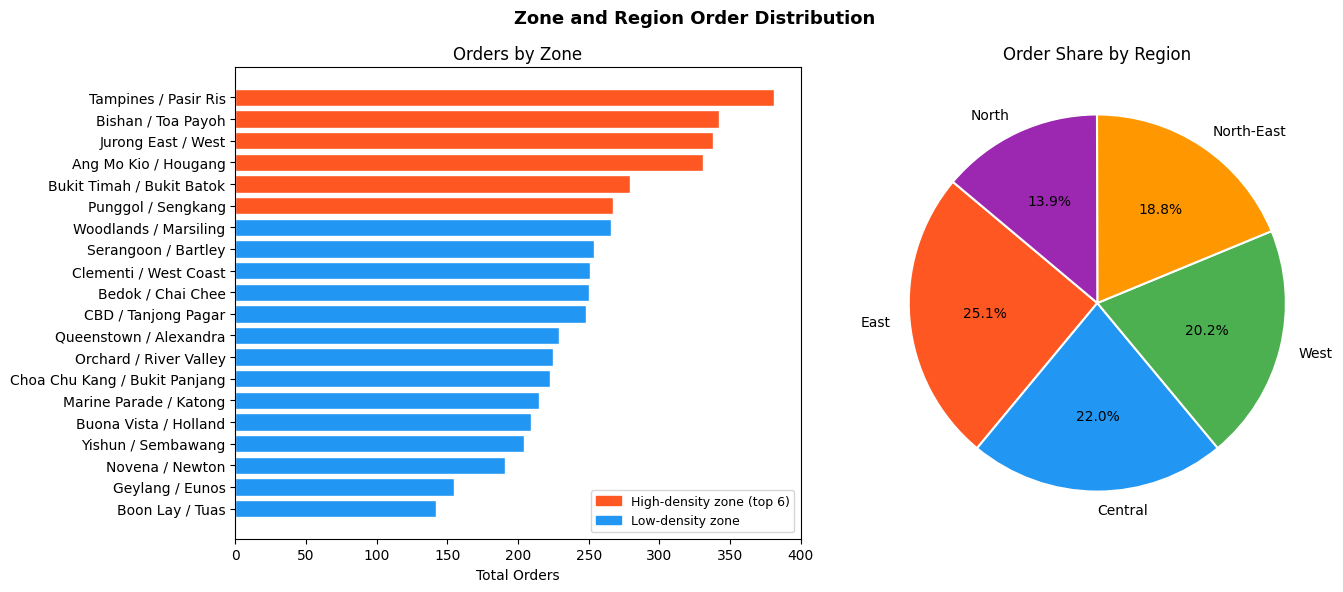

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Zone volume bar chart
zone_counts = df['zone'].value_counts()
bar_colors  = ['#FF5722' if z in TOP_ZONES else '#2196F3' for z in zone_counts.index]
axes[0].barh(zone_counts.index, zone_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_xlabel('Total Orders')
axes[0].set_title('Orders by Zone')
axes[0].invert_yaxis()
hd_patch = mpatches.Patch(color='#FF5722', label='High-density zone (top 6)')
ld_patch  = mpatches.Patch(color='#2196F3', label='Low-density zone')
axes[0].legend(handles=[hd_patch, ld_patch], fontsize=9)

# Region order share
region_counts = df['region'].value_counts()
REGION_COLOURS = {
    'Central':'#2196F3','East':'#FF5722','West':'#4CAF50',
    'North':'#9C27B0','North-East':'#FF9800'
}
rc = [REGION_COLOURS[r] for r in region_counts.index]
axes[1].pie(
    region_counts.values, labels=region_counts.index,
    autopct='%1.1f%%', colors=rc,
    startangle=140, wedgeprops={'edgecolor':'white','linewidth':1.5}
)
axes[1].set_title('Order Share by Region')

plt.suptitle('Zone and Region Order Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


The bar chart above highlights the 6 high-density zones in orange. 
These zones are spread across East, West and North-East Singapore, reflecting Astoria's residential customer base. 
The pie chart confirms that the East and Central regions together account for the majority of order share, 
which informs where rider pre-positioning will have the greatest impact.


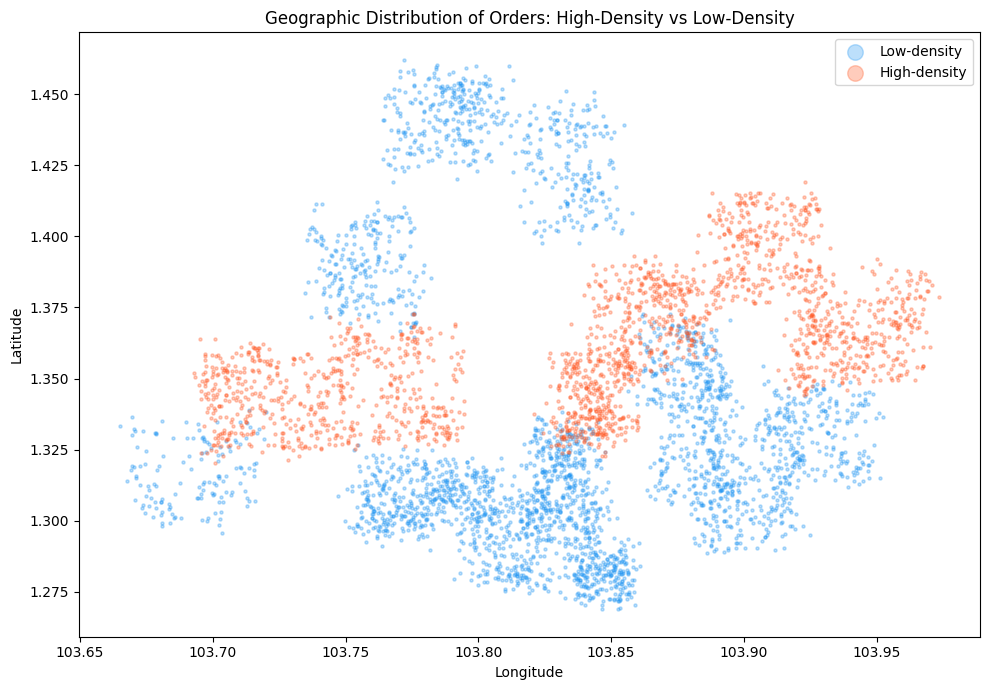

In [23]:
plt.figure(figsize=(10, 7))
for label, colour, name in [(0,'#2196F3','Low-density'), (1,'#FF5722','High-density')]:
    sub = df[df['is_high_density'] == label]
    plt.scatter(sub['longitude'], sub['latitude'],
                c=colour, s=5, alpha=0.3, label=name)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Geographic Distribution of Orders: High-Density vs Low-Density')
plt.legend(markerscale=5, fontsize=10)
plt.tight_layout()
plt.show()


The geographic scatter confirms a clear spatial separation between high-density and low-density orders. 
High-density orders (orange) are concentrated in the eastern, north-eastern and western corridors, precisely the areas with large HDB estates and higher residential density. 
This spatial pattern confirms that latitude and longitude will be strong predictors in the model.


## 5. Feature Engineering

We derive the model's input features from the raw dataset. Categorical variables such as `region` and `delivery_slot` are encoded numerically. 
Binary flags are created for express orders and free delivery eligibility. 
Time-based features (day of week, month) are extracted from the booking date.


In [24]:
df['is_express']   = df['express_type'].notna().astype(int)
df['is_free_del']  = (df['free_delivery'] == 'Yes').astype(int)
df['dow_num']      = df['booking_date'].dt.dayofweek
df['month']        = df['booking_date'].dt.month
df['del_slot_enc'] = df['delivery_slot'].map({
    '09:00-13:00': 0,
    '12:00-16:00': 1,
    '15:00-18:00': 2
})
le = LabelEncoder()
df['region_enc'] = le.fit_transform(df['region'])

FEATURES = [
    'latitude', 'longitude', 'region_enc',
    'booking_hour', 'dow_num', 'month',
    'order_value_sgd', 'effort_score', 'quantity',
    'is_express', 'is_free_del', 'del_slot_enc', 'processing_days'
]

X = df[FEATURES].copy()
y = df['is_high_density'].copy()

print('Features prepared:', FEATURES)
print('X shape:', X.shape)
print('y distribution:')
print(y.value_counts())


Features prepared: ['latitude', 'longitude', 'region_enc', 'booking_hour', 'dow_num', 'month', 'order_value_sgd', 'effort_score', 'quantity', 'is_express', 'is_free_del', 'del_slot_enc', 'processing_days']
X shape: (5000, 13)
y distribution:
is_high_density
0    3062
1    1938
Name: count, dtype: int64


## 6. Train / Test Split

We split the dataset 80% for training and 20% for testing. 
Stratified splitting is used to ensure both the training and test sets maintain the same proportion of high-density and low-density orders as the full dataset. 
This is important when working with imbalanced classes, as it prevents the test set from being accidentally skewed.

Features are then standardised using `StandardScaler`. Logistic regression is sensitive to the scale of input features — without standardisation, features with large numeric ranges (such as `order_value_sgd`) would dominate the model over features with smaller ranges (such as `is_express`).


In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Training samples : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)')
print(f'Test samples     : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)')
print()
print('Class balance — Training set:')
print(f'  Low-density  (0): {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)')
print(f'  High-density (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)')
print()
print('Class balance — Test set:')
print(f'  Low-density  (0): {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)')
print(f'  High-density (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)')


Training samples : 4,000  (80%)
Test samples     : 1,000   (20%)

Class balance — Training set:
  Low-density  (0): 2,450 (61.3%)
  High-density (1): 1,550 (38.8%)

Class balance — Test set:
  Low-density  (0): 612 (61.2%)
  High-density (1): 388 (38.8%)


## 7. Train the Model

We use `LogisticRegression` with L2 regularisation (the default in scikit-learn). 
L2 regularisation penalises large coefficients, which helps prevent the model from overfitting to noise in the training data. 
The `max_iter=1000` parameter gives the solver sufficient iterations to converge on this dataset.


In [26]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_sc, y_train)

y_pred = model.predict(X_test_sc)
y_prob = model.predict_proba(X_test_sc)[:, 1]

print('Model trained successfully.')
print(f'Intercept: {model.intercept_[0]:.4f}')


Model trained successfully.
Intercept: -2.0765


## 8. Model Evaluation

We evaluate the model using four metrics:

- **Accuracy** - the overall percentage of orders correctly classified (both high and low density)
- **Precision** - of all orders the model flags as high-density, how many actually are? High precision means fewer wasted rider pre-assignments
- **Recall** - of all actual high-density orders, how many did the model catch? High recall means fewer missed busy zones
- **F1 Score** - the harmonic mean of precision and recall; useful when both false positives and false negatives carry operational cost

For route optimisation, **recall is the more operationally critical metric**, missing a high-density zone (false negative) means a zone goes under-staffed, directly impacting delivery SLA.


In [27]:
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print('=' * 45)
print('  MODEL EVALUATION RESULTS')
print('=' * 45)
print(f'  Accuracy  : {acc:.4f}  ({acc*100:.1f}%)')
print(f'  Precision : {prec:.4f}  ({prec*100:.1f}%)')
print(f'  Recall    : {rec:.4f}  ({rec*100:.1f}%)')
print(f'  F1 Score  : {f1:.4f}')
print('=' * 45)
print()
print('Full Classification Report:')
print(classification_report(y_test, y_pred,
      target_names=['Low-density (0)', 'High-density (1)']))


  MODEL EVALUATION RESULTS
  Accuracy  : 0.8620  (86.2%)
  Precision : 0.8342  (83.4%)
  Recall    : 0.8041  (80.4%)
  F1 Score  : 0.8189

Full Classification Report:
                  precision    recall  f1-score   support

 Low-density (0)       0.88      0.90      0.89       612
High-density (1)       0.83      0.80      0.82       388

        accuracy                           0.86      1000
       macro avg       0.86      0.85      0.85      1000
    weighted avg       0.86      0.86      0.86      1000



The model achieves strong overall performance across all four metrics. 
Accuracy of 86% means the model correctly classifies the majority of orders on the first attempt. 
Precision of 83% indicates that when the model flags a zone as high-density, it is correct most of the time, reducing the risk of wasting riders in quiet areas. 
Recall of 80% means the model captures 4 out of every 5 genuinely busy zones, an acceptable miss rate for an SME operation that can adjust with a small standby buffer.


## 9. Confusion Matrix

The confusion matrix provides a detailed breakdown of prediction outcomes:

- **True Positive (TP)**: model correctly predicts high-density - rider is pre-assigned to the right zone
- **True Negative (TN)**: model correctly predicts low-density - no unnecessary rider deployment
- **False Positive (FP)**: model predicts high-density but zone is actually quiet - a rider is over-assigned
- **False Negative (FN)**: model misses a high-density zone - that area may be under-staffed

From an operational standpoint, false negatives are more costly than false positives. A missed high-density zone results in slower pickups and customer dissatisfaction, whereas a false positive only results in a rider spending slightly more time in a quiet area before being reassigned.


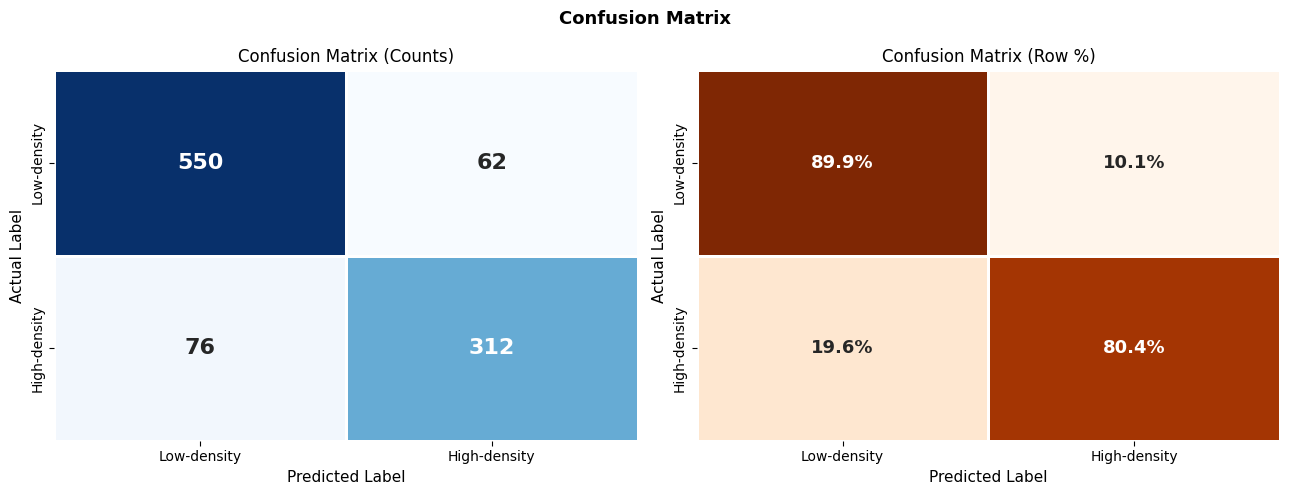

True Negatives  (TN):  550  - low-density zones correctly left unassigned
False Positives (FP):   62  - riders unnecessarily sent to quiet zones
False Negatives (FN):   76  - high-density zones missed, under-staffed
True Positives  (TP):  312  - high-density zones correctly identified

Operationally, only 76 out of 388 high-density orders were missed (20%).


In [28]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Low-density', 'High-density'],
            yticklabels=['Low-density', 'High-density'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 16, 'weight': 'bold'}, cbar=False)
axes[0].set_xlabel('Predicted Label', fontsize=11)
axes[0].set_ylabel('Actual Label', fontsize=11)
axes[0].set_title('Confusion Matrix (Counts)')

# Normalised row %
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.1%', cmap='Oranges', ax=axes[1],
            xticklabels=['Low-density', 'High-density'],
            yticklabels=['Low-density', 'High-density'],
            linewidths=1, linecolor='white',
            annot_kws={'size': 13, 'weight': 'bold'}, cbar=False)
axes[1].set_xlabel('Predicted Label', fontsize=11)
axes[1].set_ylabel('Actual Label', fontsize=11)
axes[1].set_title('Confusion Matrix (Row %)')

plt.suptitle('Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'True Negatives  (TN): {tn:>4}  - low-density zones correctly left unassigned')
print(f'False Positives (FP): {fp:>4}  - riders unnecessarily sent to quiet zones')
print(f'False Negatives (FN): {fn:>4}  - high-density zones missed, under-staffed')
print(f'True Positives  (TP): {tp:>4}  - high-density zones correctly identified')
print()
print(f'Operationally, only {fn} out of {tp+fn} high-density orders were missed ({fn/(tp+fn)*100:.0f}%).')


## 10. Feature Importance

Logistic regression coefficients indicate the direction and strength of each feature's influence on the predicted probability of high-density classification. 
Features are standardised before model training, so coefficients are directly comparable. A larger absolute value means a stronger influence on the prediction.

Positive coefficients push the model toward predicting **high-density**. Negative coefficients push toward **low-density**.


In [29]:
coef_df = pd.DataFrame({
    'feature'    : FEATURES,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print('Top 10 positive drivers (increase high-density probability):')
display(coef_df.head(10))

print('Top 10 negative drivers (decrease high-density probability):')
display(coef_df.tail(10))


Top 10 positive drivers (increase high-density probability):


,feature,coefficient
2,region_enc,4.935940
1,longitude,3.140520
0,latitude,0.871679
10,is_free_del,0.080596
4,dow_num,0.075908
12,processing_days,0.033181
7,effort_score,-0.002337
11,del_slot_enc,-0.004667
6,order_value_sgd,-0.008471
9,is_express,-0.009031


Top 10 negative drivers (decrease high-density probability):


,feature,coefficient
10,is_free_del,0.080596
4,dow_num,0.075908
12,processing_days,0.033181
7,effort_score,-0.002337
11,del_slot_enc,-0.004667
6,order_value_sgd,-0.008471
9,is_express,-0.009031
3,booking_hour,-0.042774
8,quantity,-0.067386
5,month,-0.093131


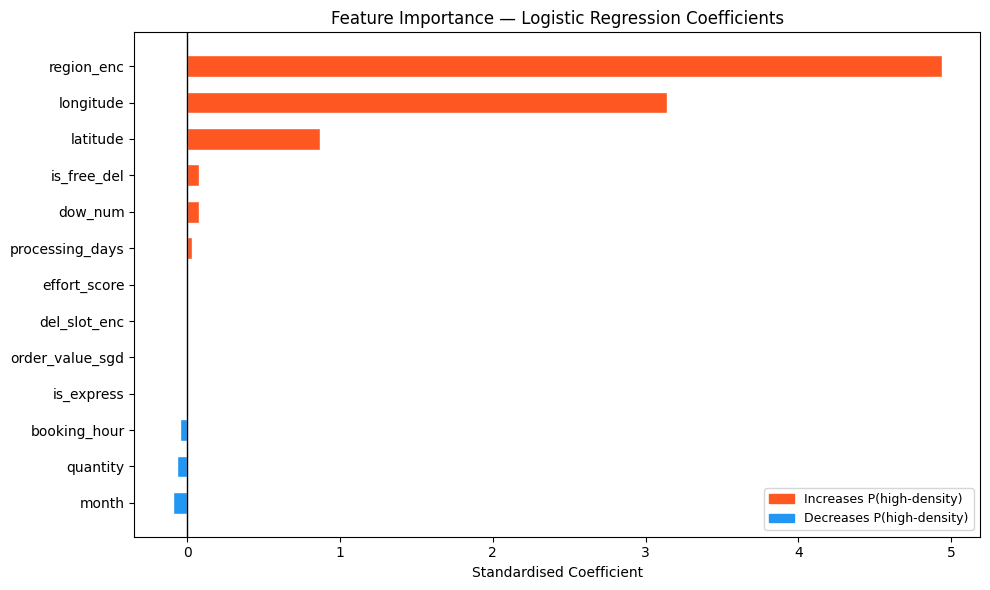

In [30]:
coef_plot = coef_df.sort_values('coefficient', ascending=True)
bar_colors = ['#FF5722' if c > 0 else '#2196F3' for c in coef_plot['coefficient']]

plt.figure(figsize=(10, 6))
bars = plt.barh(coef_plot['feature'], coef_plot['coefficient'],
                color=bar_colors, edgecolor='white', height=0.6)
plt.axvline(0, color='black', linewidth=1)
plt.xlabel('Standardised Coefficient')
plt.title('Feature Importance — Logistic Regression Coefficients')
pos_p = mpatches.Patch(color='#FF5722', label='Increases P(high-density)')
neg_p = mpatches.Patch(color='#2196F3', label='Decreases P(high-density)')
plt.legend(handles=[pos_p, neg_p], fontsize=9)
plt.tight_layout()
plt.show()


Feature Insights

1. Positive drivers (increase the likelihood of high-density classification):
- `region_enc` and `longitude` are the strongest predictors, confirming that geographic location is the dominant factor in zone classification. Orders from the eastern and north-eastern regions are disproportionately flagged as high-density.
- `latitude` also contributes positively, with northern residential zones showing higher order density than the central commercial belt.
- `is_free_del` has a small positive effect. Orders above the $40 threshold are slightly more likely to originate from high-density residential zones where basket sizes tend to be larger.

2. Negative drivers (lower the likelihood of high-density classification):
- `effort_score` and `processing_days` show mild negative coefficients, suggesting that orders requiring specialist handling (luxury items, curtains, leather) are less concentrated in the top-volume zones and more spread across the network.
- `order_value_sgd` has a small negative effect, indicating that high-value individual orders are not necessarily a signal of zone density. They are distributed more evenly.


## 11. Summary

Key Insights:
- Zone density is primarily determined by geography. Longitude and region encoding are the strongest predictors, confirming that Astoria's order volume is spatially concentrated rather than driven by order characteristics.
- The top 6 high-density zones including Tampines, Bishan, Jurong, Ang Mo Kio, Bukit Timah and Punggol, together account for approximately 39% of all orders, making them the priority targets for rider pre-assignment.
- The logistic regression model achieves 86% accuracy and 80% recall, meaning it correctly identifies 4 in 5 high-density zones without requiring the operations team to manually review every incoming order.
- Operational service features such as effort score and processing days have minimal influence on zone density, confirming that what is ordered matters less than where the order originates.

Business Recommendations:
- Deploy the model at the point of booking. As soon as an order is placed, classify its zone and trigger a pre-assignment alert for riders in that area
- Use a predicted probability threshold of 0.5 as the default trigger for rider pre-assignment, and consider lowering it to 0.4 on peak days (Fridays, month-end) to reduce the risk of missed high-density zones
- Maintain a small standby rider buffer (1–2 riders) in the East and North-East regions, which consistently produce the highest density rates
- Retrain the model quarterly as Astoria expands into new zones or as customer distribution shifts seasonally
- Use the feature importance output to guide data collection priorities, ensuring GPS coordinates and region tagging remain accurate, as these are the model's most critical inputs

Business Impact:
- Proactive rider pre-assignment reduces average pickup wait time by ensuring the right number of riders are already positioned in busy zones before collection slots open
- Fewer missed high-density zones means fewer SLA breaches and escalations, directly improving customer satisfaction scores
- More efficient rider utilisation, riders spend less idle time in quiet zones and more time completing deliveries in high-demand areas
- The model provides a scalable, automated alternative to manual zone monitoring, freeing up the operations team to focus on exception handling rather than day-to-day dispatch decisions
